In [1]:
import healpy
import healpy as hp
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
jax.config.update("jax_enable_x64", True)

In [2]:
def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

dtype_r = jnp.float64
DEFAULT_NSIDE = 32
# DEFAULT_NSIDE = 64
# DEFAULT_NSIDE = 16
# DEFAULT_NSIDE = 8
# DEFAULT_NSIDE = 128
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

In [3]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
s11_aut = np.loadtxt( '/Users/dominiv/research/data/S11_AUT.csv', delimiter=',', skiprows=1)
s12_atu_t = np.loadtxt('/Users/dominiv/research/data/S12_AUT_to_Trans.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361
print(s11_transmitter.shape)

(72561, 4)


In [4]:
bowtie_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

bowtie_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

bowtie_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

bowtie_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

bowtie_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

dipole_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Imaginaryl_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

dipole_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

dipole_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

### check file names, i think i messed some up
bowtie_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

nside = DEFAULT_NSIDE
npix = hp.nside2npix(nside)
beam_thetas = np.deg2rad(bowtie_x_gain_100[:, 1])
beam_phis =   np.deg2rad(bowtie_x_gain_100[:, 0])

def hfss_map(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap


# ek = 1
ek = 8

bowtie_x_beam_100 = hfss_map(bowtie_x_gain_100)
bowtie_x_beam_150 = hfss_map(bowtie_x_gain_150)
bowtie_x_beam_200 = hfss_map(bowtie_x_gain_200)
bowtie_x_beam_250 = hfss_map(bowtie_x_gain_250)

bowtie_y_beam_100 = hfss_map(bowtie_y_gain_100)
bowtie_y_beam_150 = hfss_map(bowtie_y_gain_150)
bowtie_y_beam_200 = hfss_map(bowtie_y_gain_200)
bowtie_y_beam_250 = hfss_map(bowtie_y_gain_250)

bowtie_z_beam_100 = hfss_map(bowtie_z_gain_100)
bowtie_z_beam_150 = hfss_map(bowtie_z_gain_150)
bowtie_z_beam_200 = hfss_map(bowtie_z_gain_200)
bowtie_z_beam_250 = hfss_map(bowtie_z_gain_250)

dipole_x_beam_100 = hfss_map(dipole_x_gain_100)
dipole_x_beam_150 = hfss_map(dipole_x_gain_150)
dipole_x_beam_200 = hfss_map(dipole_x_gain_200)
dipole_x_beam_250 = hfss_map(dipole_x_gain_250)

dipole_y_beam_100 = hfss_map(dipole_y_gain_100)
dipole_y_beam_150 = hfss_map(dipole_y_gain_150)
dipole_y_beam_200 = hfss_map(dipole_y_gain_200)
dipole_y_beam_250 = hfss_map(dipole_y_gain_250)

dipole_z_beam_100 = hfss_map(dipole_z_gain_100)
dipole_z_beam_150 = hfss_map(dipole_z_gain_150)
dipole_z_beam_200 = hfss_map(dipole_z_gain_200)
dipole_z_beam_250 = hfss_map(dipole_z_gain_250)

bowtie_theta_beam_100 = hfss_map(bowtie_theta_gain_100)
bowtie_theta_beam_150 = hfss_map(bowtie_theta_gain_150)
bowtie_theta_beam_200 = hfss_map(bowtie_theta_gain_200)
bowtie_theta_beam_250 = hfss_map(bowtie_theta_gain_250)

bowtie_phi_beam_100 = hfss_map(bowtie_phi_gain_100)
bowtie_phi_beam_150 = hfss_map(bowtie_phi_gain_150)
bowtie_phi_beam_200 = hfss_map(bowtie_phi_gain_200)
bowtie_phi_beam_250 = hfss_map(bowtie_phi_gain_250)

dipole_theta_imag_100_map = hfss_map(dipole_theta_imag_100, k=ek)
dipole_theta_real_100_map = hfss_map(dipole_theta_real_100, k=ek)
dipole_phi_imag_100_map = hfss_map(dipole_phi_imag_100, k=ek)
dipole_phi_real_100_map = hfss_map(dipole_phi_real_100, k=ek)

bowtie_theta_imag_100_map = hfss_map(bowtie_theta_imag_100, k=ek)
bowtie_theta_real_100_map = hfss_map(bowtie_theta_real_100, k=ek)
bowtie_phi_imag_100_map =   hfss_map(bowtie_phi_imag_100, k=ek)
bowtie_phi_real_100_map =   hfss_map(bowtie_phi_real_100, k=ek)

dipole_theta_imag_150_map = hfss_map(dipole_theta_imag_150)
dipole_theta_real_150_map = hfss_map(dipole_theta_real_150)
dipole_phi_imag_150_map =   hfss_map(dipole_phi_imag_150)
dipole_phi_real_150_map =   hfss_map(dipole_phi_real_150)

bowtie_theta_imag_150_map = hfss_map(bowtie_theta_imag_150)
bowtie_theta_real_150_map = hfss_map(bowtie_theta_real_150)
bowtie_phi_imag_150_map =   hfss_map(bowtie_phi_imag_150)
bowtie_phi_real_150_map =   hfss_map(bowtie_phi_real_150)

dipole_theta_imag_200_map = hfss_map(dipole_theta_imag_200)
dipole_theta_real_200_map = hfss_map(dipole_theta_real_200)
dipole_phi_imag_200_map =   hfss_map(dipole_phi_imag_200)
dipole_phi_real_200_map =   hfss_map(dipole_phi_real_200)

bowtie_theta_imag_200_map = hfss_map(bowtie_theta_imag_200)
bowtie_theta_real_200_map = hfss_map(bowtie_theta_real_200)
bowtie_phi_imag_200_map =   hfss_map(bowtie_phi_imag_200)
bowtie_phi_real_200_map =   hfss_map(bowtie_phi_real_200)

dipole_theta_imag_250_map = hfss_map(dipole_theta_imag_250)
dipole_theta_real_250_map = hfss_map(dipole_theta_real_250)
dipole_phi_imag_250_map =   hfss_map(dipole_phi_imag_250)
dipole_phi_real_250_map =   hfss_map(dipole_phi_real_250)

bowtie_theta_imag_250_map = hfss_map(bowtie_theta_imag_250)
bowtie_theta_real_250_map = hfss_map(bowtie_theta_real_250)
bowtie_phi_imag_250_map =   hfss_map(bowtie_phi_imag_250)
bowtie_phi_real_250_map =   hfss_map(bowtie_phi_real_250)

dipole_xi_beam_100 = hfss_map(dipole_xi_gain_100, k=ek)
dipole_xr_beam_100 = hfss_map(dipole_xr_gain_100, k=ek)
dipole_yi_beam_100 = hfss_map(dipole_yi_gain_100, k=ek)
dipole_yr_beam_100 = hfss_map(dipole_yr_gain_100, k=ek)
dipole_zi_beam_100 = hfss_map(dipole_zi_gain_100, k=ek)
dipole_zr_beam_100 = hfss_map(dipole_zr_gain_100, k=ek)

bowtie_xi_beam_100 = hfss_map(bowtie_xi_gain_100, k=ek)
bowtie_xr_beam_100 = hfss_map(bowtie_xr_gain_100, k=ek)
bowtie_yi_beam_100 = hfss_map(bowtie_yi_gain_100, k=ek)
bowtie_yr_beam_100 = hfss_map(bowtie_yr_gain_100, k=ek)
bowtie_zi_beam_100 = hfss_map(bowtie_zi_gain_100, k=ek)
bowtie_zr_beam_100 = hfss_map(bowtie_zr_gain_100, k=ek)

dipole_xi_beam_200 = hfss_map(dipole_xi_gain_200, k=ek)
dipole_xr_beam_200 = hfss_map(dipole_xr_gain_200, k=ek)
dipole_yi_beam_200 = hfss_map(dipole_yi_gain_200, k=ek)
dipole_yr_beam_200 = hfss_map(dipole_yr_gain_200, k=ek)
dipole_zi_beam_200 = hfss_map(dipole_zi_gain_200, k=ek)
dipole_zr_beam_200 = hfss_map(dipole_zr_gain_200, k=ek)

bowtie_xi_beam_200 = hfss_map(bowtie_xi_gain_200, k=ek)
bowtie_xr_beam_200 = hfss_map(bowtie_xr_gain_200, k=ek)
bowtie_yi_beam_200 = hfss_map(bowtie_yi_gain_200, k=ek)
bowtie_yr_beam_200 = hfss_map(bowtie_yr_gain_200, k=ek)
bowtie_zi_beam_200 = hfss_map(bowtie_zi_gain_200, k=ek)
bowtie_zr_beam_200 = hfss_map(bowtie_zr_gain_200, k=ek)

dipole_xi_beam_250 = hfss_map(dipole_xi_gain_250, k=ek)
dipole_xr_beam_250 = hfss_map(dipole_xr_gain_250, k=ek)
dipole_yi_beam_250 = hfss_map(dipole_yi_gain_250, k=ek)
dipole_yr_beam_250 = hfss_map(dipole_yr_gain_250, k=ek)
dipole_zi_beam_250 = hfss_map(dipole_zi_gain_250, k=ek)
dipole_zr_beam_250 = hfss_map(dipole_zr_gain_250, k=ek)

bowtie_xi_beam_250 = hfss_map(bowtie_xi_gain_250, k=ek)
bowtie_xr_beam_250 = hfss_map(bowtie_xr_gain_250, k=ek)
bowtie_yi_beam_250 = hfss_map(bowtie_yi_gain_250, k=ek)
bowtie_yr_beam_250 = hfss_map(bowtie_yr_gain_250, k=ek)
bowtie_zi_beam_250 = hfss_map(bowtie_zi_gain_250, k=ek)
bowtie_zr_beam_250 = hfss_map(bowtie_zr_gain_250, k=ek)

dipole_theta_beam_100 = hfss_map(dipole_theta_gain_100)
dipole_phi_beam_100 = hfss_map(dipole_phi_gain_100)

In [14]:
phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)
# s11_t = np.reshape(s11_t, newshape=(inc, s11_t.shape[0]//inc))

s11_bowtie = db_lin(s11_aut[:, 3])
s11_bowtie = s11_bowtie.reshape(ang, inc)
# s11_bowtie = np.reshape(s11_bowtie, newshape=(inc, s11_bowtie.shape[0]//inc))

s12_bowtie = db_lin(s12_atu_t[:, 3])
s12_bowtie = s12_bowtie.reshape(ang, inc)
# s12_bowtie = np.reshape(s12_bowtie, newshape=(inc, s12_bowtie.shape[0]//inc))
phis.shape, thetas.shape, freqs.shape, s11_t.shape, s11_bowtie.shape, s12_bowtie.shape

((361,), (361,), (201,), (361, 201), (361, 201), (361, 201))

In [5]:
def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat

DEFAULT_BEAM_X = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Y = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Z = jnp.copy(DEFAULT_BEAM_TH)


@jax.tree_util.register_pytree_node_class
class RotatingAntenna:
    # def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI, 
    def __init__(self, beam_x=DEFAULT_BEAM_X, beam_y=DEFAULT_BEAM_Y, beam_z=DEFAULT_BEAM_Z,
                 el_ax=jnp.array([1, 0, 0], dtype=dtype_r),
                az_ax=jnp.array([0, 0, 1], dtype=dtype_r)):
        # self.pwr_beam_th  = jnp.asarray(beam_th)
        # self.pwr_beam_phi = jnp.asarray(beam_phi)
        self.pwr_beam_x  = jnp.asarray(beam_x)
        self.pwr_beam_y  = jnp.asarray(beam_y)
        self.pwr_beam_z  = jnp.asarray(beam_z)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_x)))
        # rotation axes in your convention
        self.el_axis = el_ax
        self.az_axis = az_ax
        # self.el_axis = jnp.array([0, 1, 0], dtype=dtype_r)
        # self.az_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        # leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        leaves = (self.pwr_beam_x, self.pwr_beam_y, self.pwr_beam_z, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        # pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        pwr_beam_x, pwr_beam_y, pwr_beam_z, el_axis, az_axis = leaves
        # obj = cls(pwr_beam_th, pwr_beam_phi)
        obj = cls(pwr_beam_x, pwr_beam_y, pwr_beam_z)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj


    def rotation(self, az, el): ### Added
        xg = self.el_axis
        zg = self.az_axis
        # xg = jnp.array([0.0, 1.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
        # xg = jnp.array([1.0, 0.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
    
        R_az = rot_m(az, zg)   # about global Z
        R_el = rot_m(el, xg)   # about global X
    
        # apply az first, then el (rightmost happens first)
        return (R_el @ R_az) ### Added
        # return (R_az @ R_el).T ### Added

    # ---- rotation (your original order) ----
    # def rotation(self, az, el): ### original
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
        # return R_az @ R_el
    # def rotation(self, az, el):
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
    #     # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    
    # def r_hat(self, th, phi): # XXX original
    #     shape = th.shape
    #     r_hat = jnp.empty(shape + (3,), dtype=dtype_r)
    #     # r_hat[..., 2] = jnp.cos(th)
    #     r_hat = r_hat.at[..., 2].set(jnp.cos(th))
    #     xy = jnp.sin(th)
    #     # r_hat[..., 0] = jnp.cos(phi) * xy
    #     # r_hat[..., 1] = jnp.sin(phi) * xy
    #     r_hat = r_hat.at[..., 0].set(jnp.cos(phi) * xy)
    #     r_hat = r_hat.at[..., 1].set(jnp.sin(phi) * xy)
    #     return r_hat
        
    # def phi_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = jnp.cross(jnp.array([0, 0, 1]), r_hat)
    #     phi_hat /= jnp.linalg.norm(phi_hat, axis=-1, keepdims=True)
    #     return phi_hat

    # def th_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = self.phi_hat(th, phi)
    #     return jnp.cross(r_hat, phi_hat)
    #     # return jnp.cross(phi_hat, r_hat) # XXX original

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)

    # ---- power kernels (unchanged API; now consistent with θ flip) ----
    def power_transmitter(self, tx_ant, az, el):
        R = self.rotation(az, el)
        th_tx, phi_tx = tx_ant.heading_thphi(R)
        E_tx_rot = tx_ant.E_rotated(R)
        px = self.ang2pix(th_tx, phi_tx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        P_rx_th  = self.pwr_beam_th[px]  * (E_tx_th**2)
        P_rx_phi = self.pwr_beam_phi[px] * (E_tx_phi**2)
        return P_rx_th + P_rx_phi

    def power_transmitter_jax(self, tx_ant, rot_mx, th_tx, phi_tx, px):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        return self.pwr_beam_th[px]*(E_tx_th**2) + self.pwr_beam_phi[px]*(E_tx_phi**2)

    def power_transmitter_jax_pure(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   pwr_beam_th, pwr_beam_phi):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        # return jnp.sum(jnp.abs(jnp.dot(self.pvec, E_tx_rot.T))**2)
        th_hat   = self.th_hat(th_tx, phi_tx)
        phi_hat  = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        # E_tx_th  = jnp.dot(th_hat, E_tx_rot)
        # E_tx_phi = jnp.dot(phi_hat, E_tx_rot)
        px = jax.lax.convert_element_type(px, jnp.int32)
        g_th  = jax.lax.dynamic_index_in_dim(pwr_beam_th,  px, axis=0, keepdims=False)
        g_phi = jax.lax.dynamic_index_in_dim(pwr_beam_phi, px, axis=0, keepdims=False)
        # return 20*jnp.log10(E_tx_th + E_tx_phi) + 20*jnp.log10(g_th + g_phi) + 20*jnp.log10((2.1927676928 / (4 * jnp.pi * 100))**2)
        # return (((g_th + g_phi) * (E_tx_th + E_tx_phi) * (2.1927676928 / (4 * jnp.pi * 100))**2))
        # return g_th*(E_tx_th) + g_phi*(E_tx_phi)
        return g_th*(E_tx_th**2) + g_phi*(E_tx_phi**2)
        # return (g_th*E_tx_th)**2 + (g_phi*E_tx_phi)**2
   
    def power_transmitter_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                      gain_th, gain_phi,   # POWER gains (linear units)
                                      delta_rx=0.0,        # unknown RX relative phase? fit this if needed
                                      K=1.0):
        E = tx_ant.E_rotated(rot_mx)                      # complex (3,)
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)                       # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        px   = jax.lax.convert_element_type(px, jnp.int32)
        Gth  = jax.lax.dynamic_index_in_dim(gain_th,  px, axis=0, keepdims=False)
        Gphi = jax.lax.dynamic_index_in_dim(gain_phi, px, axis=0, keepdims=False)
    
        # Single-port RX: complex coefficients a, b in (θ, φ) basis
        a = jnp.sqrt(Gth)                                 # magnitude from power gain
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)         # include RX relative phase if unknown
    
        V = a * Eth + b * Ephi                            # complex port voltage
        return K * (V.conj() * V).real
   
    def autocorr_power_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   Gth_lin, Gphi_lin,   # component power gains of the *RX port*
                                   delta_rx=0.0,        # relative phase between the two components (fit if unknown)
                                   K=1.0,               # overall calibration (TX power, path loss, backend units)
                                   C0=0.0):             # additive noise floor (receiver/system temp)
        # TX complex 3-vector in RX-local frame
        E = tx_ant.E_rotated(rot_mx)
    
        # Project to local spherical basis
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)      # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        # Lookup RX component gains (linear, not dB)
        px    = jax.lax.convert_element_type(px, jnp.int32)
        Gth   = jax.lax.dynamic_index_in_dim(Gth_lin,  px, axis=0, keepdims=False)
        Gphi  = jax.lax.dynamic_index_in_dim(Gphi_lin, px, axis=0, keepdims=False)
    
        # Single-port coherent combination
        a = jnp.sqrt(Gth)
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)
        V = a * Eth + b * Ephi
    
        # Auto-correlation power model (zero lag)
        return C0 + K * (V.conj() * V).real


def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0, cir=False):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2
        if cir:
            a1 = jnp.sqrt(jnp.clip(1.0, 0.0, 1.0))
            a2 = jnp.sqrt(2.0 - jnp.clip(1.0, 0.0, 1.0)) * jnp.exp(1j*jnp.pi/2)
            self.E1 = 1.0
            self.E2 = 1j*self.E1
            # self.E1 = total_amp * a1
            # self.E2 = total_amp * a2
            

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs

@jax.jit
def simulate_powers_vmap(rx, tx, az, el, E1, E2, pwr_beam_th=None, pwr_beam_phi=None):
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    def _one(R, th, ph, px):
        return rx.power_transmitter_jax_pure(
            tx, R, th, ph, px,
            pwr_beam_th=pwr_beam_th, pwr_beam_phi=pwr_beam_phi
        )
    P = jax.vmap(_one)(Rs, ths, phis, pxs)
    return P, pxs


@jax.jit
def simulate_powers_vmap_phase(rx, tx, az, el, E1, E2,                   # kept for parity
                               delta_rx=0.0,
                               pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
                               K=1.0, C0=0.0, noise=None):
    # defaults from rx
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local frame
    Es = jax.vmap(tx.E_rotated)(Rs) ### original
    # TX field in RX-local frame (current)
    # Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3)
    
    # --- NEW: enforce E ⟂ r_hat (transverse field) ---
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### just added
    Er = jnp.einsum('ij,ij->i', Es, r_hat)     ###
    Es = Es - Er[:, None] * r_hat             ###

    # local spherical basis and projections
    th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
    # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
    # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
    Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
    Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

    # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
    # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
    alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

    # gather component gains (LINEAR units; if dBi, convert upstream)
    pxs  = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

    # coherent single-port combination
    a = jnp.sqrt(Gth)  * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # auto-correlation (zero lag) power
    P = C0 + K * (V.conj() * V).real
    # component gains
    # Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)
    # Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

# incoherent sum of component powers (no alpha/beta, no delta_rx)
    # P = C0 + K * (Gth * (jnp.abs(Eth)**2) + Gphi * (jnp.abs(Ephi)**2))

    if noise != None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=(P.shape))*noise
    # return P, pxs
    return P, pxs, Eth, Ephi, alpha, beta

In [21]:
def beam_proj(px, pwr, cmap='turbo', save=False, freq=False, path=False, data=False, loss=False, vmin=0, vmax=3):
    if save:
        m = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m_dat = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        # m = m.at[px].set(jnp.log10(pwr))
        m_dat = m_dat.at[px].set(data)
        # m_dat = m_dat.at[px].set(jnp.log10(data))
        diff = m - m_dat
        plt.ioff()
        fig = plt.figure(figsize=(12, 4))
        healpy.mollview(m, fig=fig.number, sub=(2, 3, 1), title=f"Sim at {freq}",
            cmap="turbo", cbar=True)
        healpy.mollview(diff, fig=fig.number, sub=(2, 3, 2), title=f"Diff at {freq}, loss of {loss}",
            cmap="turbo", cbar=True)
        healpy.mollview(m_dat, fig=fig.number, sub=(2, 3, 3), title=f"Data at {freq}",
            cmap="turbo", cbar=True)
        ax4 = fig.add_subplot(2, 3, 4)
        ax5 = fig.add_subplot(2, 3, 5, sharex=ax4, sharey=ax4)
        ax6 = fig.add_subplot(2, 3, 6, sharex=ax4, sharey=ax4)
        axes = [ax4, ax5, ax6]
        
        sc1 = axes[0].scatter(el_inds, az_inds, c=jnp.log10(pwr), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[0].set_title('sim')
        axes[0].set_xlabel('Elevation'); axes[0].set_ylabel('Azimuth'); axes[0].grid(True)
        fig.colorbar(sc1, ax=axes[0], label='log10')
        
        sc2 = axes[1].scatter(el_inds, az_inds, c=data-pwr, s=25, cmap='turbo')#, vmin=-1, vmax=1)#, vmin=vmin, vmax=vmax)
        axes[1].set_title('Difference')
        axes[1].set_xlabel('Elevation'); axes[1].grid(True)
        fig.colorbar(sc2, ax=axes[1], label='linear')
        
        sc3 = axes[2].scatter(el_inds, az_inds, c=jnp.log10(data), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[2].set_title('data')
        axes[2].set_xlabel('Elevation'); axes[2].grid(True)
        fig.colorbar(sc3, ax=axes[2], label='log10')
        plt.subplots_adjust(left=0.06, right=0.985, top=0.95, bottom=0.08, wspace=0.28, hspace=0.38)

        # plt.tight_layout()
        fig.savefig(path + ".png", dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        m = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        plt.figure(figsize=(10, 6))
        healpy.mollview(m, cmap=cmap, min=vmin, max=vmax)
        plt.show()

In [610]:
rx_w_x = bowtie_xr_beam_100 + 1j*bowtie_xi_beam_100
rx_w_y = bowtie_yr_beam_100 + 1j*bowtie_yi_beam_100
rx_w_z = bowtie_zr_beam_100 + 1j*bowtie_zi_beam_100

# rx_w_x = bowtie_xr_beam_150 + 1j*bowtie_xi_beam_150
# rx_w_y = bowtie_yr_beam_150 + 1j*bowtie_yi_beam_150
# rx_w_z = bowtie_zr_beam_150 + 1j*bowtie_zi_beam_150

# rx_w_x = bowtie_xr_beam_200 + 1j*bowtie_xi_beam_200
# rx_w_y = bowtie_yr_beam_200 + 1j*bowtie_yi_beam_200
# rx_w_z = bowtie_zr_beam_200 + 1j*bowtie_zi_beam_200
@jax.jit
def simulate_powers_vmap_phase_Es_cart_rx_yestx(
    rx,
    tx,
    az,
    el,
    tx_E_cart,                  # shape (3,), complex, fixed world/top-frame TX field
    delta_rx=0.0,
    pwr_beam_x=None,
    pwr_beam_y=None,
    pwr_beam_z=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry in RX-fixed frame
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # local spherical basis at sampled directions in RX-fixed frame
    th_hat  = rx.th_hat(ths, phis)    # (N, 3)
    phi_hat = rx.phi_hat(ths, phis)   # (N, 3)

    # ---------------------------------------------------------------
    # TX FIELD:
    # one fixed world/top-frame field vector, rotated into RX-fixed
    # coordinates for each RX orientation
    # ---------------------------------------------------------------
    tx_E_cart = jnp.asarray(tx_E_cart)

    # Es[n] = inv(Rs[n]) @ tx_E_cart
    Es = jnp.einsum('nij,j->ni', jnp.linalg.inv(Rs), tx_E_cart) ### uses beam map
    # Es = jax.vmap(tx.E_rotated)(Rs)
    # r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### Just added to match other functions
    # Er = jnp.einsum('ij,ij->i', Es, r_hat) ### Just added to match other functions
    # Es = Es - Er[:, None] * r_hat ### Just added to match other functions

    # project incident field onto RX-local spherical basis
    # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es) * 1e-3
    # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # ---------------------------------------------------------------
    # RX PATTERN: sample Cartesian maps on RX sky
    # ---------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)
    # wy = jnp.take(rx_w_y, pxs, axis=0)
    # wz = jnp.take(rx_w_z, pxs, axis=0)
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ---------------------------------------------------------------
    # Polarization normalization
    # ---------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    # Wpow_rot_cart = jnp.sum(jnp.conj(Wxyz) * Wxyz, axis=-1).real / 1e6
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow 
    Gtot = K_E * Wpow_V2
    Epow = Epow*1e-6 * K_E ### Just added, if we convert to gain it should have its own K_E term?
    # Epow = Epow
    # lam = 3e8 / (100e6)
    lam = 2.998e8 / (100e6)

    free_space = (lam / (4*jnp.pi*10))**2
    # final power
    # P = C0 + K * (Gtot * PLF * Epow) * free_space
    P = (Gtot * PLF * Epow) * free_space

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi, Wpow_V2, Epow



@jax.jit
def simulate_powers_vmap_phase_Es_cart_rx_notx(
    rx,
    tx,
    az,
    el,
    E1,
    E2,                         # kept for parity
    delta_rx=0.0,
    pwr_beam_th=None,
    pwr_beam_phi=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    pwr_beam_x = rx.pwr_beam_x
    pwr_beam_y = rx.pwr_beam_y
    pwr_beam_z = rx.pwr_beam_z
    # defaults from rx
    # if pwr_beam_th is None:
    #     pwr_beam_th = rx.pwr_beam_th
    # if pwr_beam_phi is None:
    #     pwr_beam_phi = rx.pwr_beam_phi
    # pwr_beam_th = rx.pwr_beam_th
    # pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local/global frame, as returned by your existing code
    # shape: (N, 3), complex
    Es = jax.vmap(tx.E_rotated)(Rs)

    # local spherical basis at sampled directions
    # shape: (N, 3), real
    th_hat  = rx.th_hat(ths, phis)
    phi_hat = rx.phi_hat(ths, phis)

    # incident field projected onto local spherical basis
    # shape: (N,), complex
    # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es) * 1e-3
    # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # ------------------------------------------------------------------
    # RX PATTERN: sample Cartesian HEALPix maps, then project locally
    # ------------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)   # (N,), complex
    # wy = jnp.take(rx_w_y, pxs, axis=0)   # (N,), complex
    # wz = jnp.take(rx_w_z, pxs, axis=0)   # (N,), complex
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    # stack to vector field
    # shape: (N,3), complex
    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    # shape: (N,), complex
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ------------------------------------------------------------------
    # Polarization normalization
    # ------------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    # En = jnp.sqrt(Epow)
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    # Wn = jnp.sqrt(Wpow)
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    # lam = 3e8 / (100e6)
    lam = 2.998e8 / (100e6)
    free_space = (lam / (4*jnp.pi*10))**2

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow
    Gtot = K_E * Wpow_V2

    # final power
    P = (Gtot * PLF * Epow) * free_space *K_E

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi


    
# @jax.jit
# def simulate_powers_vmap_phase(
#     rx, tx, az, el, E1, E2,                      # kept for parity
#     delta_rx=0.0,
#     pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
#     K=1.0, C0=0.0, noise=None
# ):
#     # defaults from rx
#     if pwr_beam_x is None:
#         pwr_beam_x = rx.pwr_beam_x
#     if pwr_beam_y is None:
#         pwr_beam_y = rx.pwr_beam_y
#     if pwr_beam_z is None:
#         pwr_beam_z = rx.pwr_beam_z

#     # geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

#     # TX field in RX-local Cartesian frame
#     Es = jax.vmap(tx.E_rotated)(Rs)   # shape (N, 3)

#     # enforce transversality using the actual propagation direction
#     r_hat = rx.r_hat(ths, phis).astype(Es.dtype)   # shape (N, 3)
#     Er = jnp.einsum('ij,ij->i', Es, r_hat)
#     Es = Es - Er[:, None] * r_hat

#     # Cartesian components in RX-local frame
#     Ex = Es[:, 0]
#     Ey = Es[:, 1]
#     Ez = Es[:, 2]

#     # beam gains
#     pxs = pxs.astype(jnp.int32)
#     wx = jnp.take(pwr_beam_x, pxs, axis=0)
#     wy = jnp.take(pwr_beam_y, pxs, axis=0)
#     wz = jnp.take(pwr_beam_z, pxs, axis=0)
#     Gx = jnp.abs(wx)**2 * 1e-6
#     Gy = jnp.abs(wy)**2 * 1e-6
#     Gz = jnp.abs(wz)**2 * 1e-6

#     # coherent combination
#     a = jnp.sqrt(Gx)
#     b = jnp.sqrt(Gy) * jnp.exp(1j * delta_rx)
#     c = jnp.sqrt(Gz)
#     mu0 = 12.566e-7
#     eps0 = 8.854e-12
#     eta0 = jnp.sqrt(mu0 / eps0)
#     Pinc = 1.0

#     # lam = 3e8 / (100e6)
#     lam = 2.998e8 / (100e6)
#     free_space = (lam / (4*jnp.pi*10))**2

#     K_E = 4 * jnp.pi / (2 * eta0 * Pinc)


#     V = a * Ex + b * Ey + c * Ez

#     # power
#     P = (V.conj() * V).real * K_E * free_space * K_E

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=P.shape) * noise

#     return P, pxs, Ex, Ey, Ez


# @jax.jit
# def simulate_powers_vmap_phase(
#     rx, tx, az, el, E1, E2,                      # kept for parity
#     delta_rx=0.0,
#     pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
#     K=1.0, C0=0.0, noise=None
# ):
#     # defaults from rx
#     if pwr_beam_x is None:
#         pwr_beam_x = rx.pwr_beam_x
#     if pwr_beam_y is None:
#         pwr_beam_y = rx.pwr_beam_y
#     if pwr_beam_z is None:
#         pwr_beam_z = rx.pwr_beam_z

#     # geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

#     # TX field in RX-local Cartesian frame
#     Es = jax.vmap(tx.E_rotated)(Rs)   # (N, 3)

#     # enforce transversality using the actual propagation direction
#     r_hat = rx.r_hat(ths, phis).astype(Es.dtype)   # (N, 3)
#     Er = jnp.einsum('ij,ij->i', Es, r_hat)
#     # Es = Es - Er[:, None] * r_hat

#     # Cartesian components in RX-local frame
#     Ex = Es[:, 0]
#     Ey = Es[:, 1]
#     Ez = Es[:, 2]

#     # beam gains
#     pxs = pxs.astype(jnp.int32)
#     wx = jnp.take(pwr_beam_x, pxs, axis=0)
#     wy = jnp.take(pwr_beam_y, pxs, axis=0)
#     wz = jnp.take(pwr_beam_z, pxs, axis=0)

#     Gx = jnp.abs(wx) ** 2 * 1e-6
#     Gy = jnp.abs(wy) ** 2 * 1e-6
#     Gz = jnp.abs(wz) ** 2 * 1e-6

#     # coherent combination coefficients
#     a = jnp.sqrt(Gx)
#     b = jnp.sqrt(Gy) * jnp.exp(1j * delta_rx)
#     c = jnp.sqrt(Gz)

#     # constants
#     mu0 = 12.566e-7
#     eps0 = 8.854e-12
#     eta0 = jnp.sqrt(mu0 / eps0)
#     Pinc = 1.0

#     lam = 2.998e8 / (100e6)
#     free_space = (lam / (4 * jnp.pi * 10)) ** 2
#     K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

#     # coherent receive voltage
#     V = a * Ex + b * Ey + c * Ez

#     # --- implicit Cartesian PLF ---
#     E_vec = jnp.stack([Ex, Ey, Ez], axis=-1)
#     h_vec = jnp.stack([a, b, c], axis=-1)

#     En = jnp.maximum(jnp.linalg.norm(E_vec, axis=-1, keepdims=True), 1e-30)
#     Hn = jnp.maximum(jnp.linalg.norm(h_vec, axis=-1, keepdims=True), 1e-30)

#     p_inc = E_vec / En
#     p_rx  = h_vec / Hn

#     PLF = jnp.abs(jnp.sum(jnp.conj(p_rx) * p_inc, axis=-1)) ** 2

#     # power
#     P = (V.conj() * V).real * K_E * free_space * K_E

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=P.shape) * noise

#     return P, pxs, Ex, Ey, Ez, PLF


@jax.jit
def simulate_powers_vmap_phase(
    rx, tx, az, el, E1, E2,                      # kept for parity
    delta_rx=0.0,
    pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
    K=1.0, C0=0.0, noise=None
):
    # defaults from rx: complex Cartesian field-response components
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

    # enforce transversality on TX field
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype)
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    # local spherical basis
    th_hat  = rx.th_hat(ths, phis).astype(Es.dtype)    # (N,3)
    phi_hat = rx.phi_hat(ths, phis).astype(Es.dtype)   # (N,3)

    # TX field projected into local spherical basis
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # sample RX Cartesian complex field-response components
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)
    Wxyz = jnp.stack([wx, wy, wz], axis=-1).astype(Es.dtype)

    # enforce transversality on RX response too
    Wr = jnp.einsum('ij,ij->i', Wxyz, r_hat)
    Wxyz = Wxyz - Wr[:, None] * r_hat

    # convert RX Cartesian field-response vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # convert field components -> power quantities
    # if maps are in mV field units, then power-like quantity is V^2 with 1e-6
    Gth  = jnp.abs(wth) ** 2 * 1e-6
    Gphi = jnp.abs(wphi) ** 2 * 1e-6

    # same geometric mixing as old spherical function
    ex_axis = jnp.array([1, 0, 0])
    # ex = rx.az_axis / jnp.linalg.norm(rx.az_axis)
    ex = ex_axis / jnp.linalg.norm(ex_axis)
    ex = ex.astype(Es.dtype)

    alpha = jnp.einsum('j,ij->i', ex, th_hat).real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat).real

    # coherent single-port combination
    a = jnp.sqrt(Gth) * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # implicit PLF for diagnostics
    E_vec_sph = jnp.stack([Eth, Ephi], axis=-1)
    h_vec_sph = jnp.stack([a, b], axis=-1)

    En = jnp.maximum(jnp.linalg.norm(E_vec_sph, axis=-1, keepdims=True), 1e-30)
    Hn = jnp.maximum(jnp.linalg.norm(h_vec_sph, axis=-1, keepdims=True), 1e-30)

    p_inc = E_vec_sph / En
    p_rx  = h_vec_sph / Hn
    PLF = jnp.abs(jnp.sum(jnp.conj(p_rx) * p_inc, axis=-1)) ** 2

    # power
    P = C0 + K * (V.conj() * V).real

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, PLF

In [611]:
# ind_check = 13 ### 100ish MHz
# ind_check = 26 ### 150ish MHz
ind_check = 38 ### 200ish MHz

delta_rx = 0

coord = jnp.array([0.0, -0.0, -1.0]) ### best
el_ax = jnp.array([0.0, 1.0, 0.0], dtype=dtype_r) ### best
az_ax = jnp.array([0.0, 0.0, 1.0], dtype=dtype_r) ### best
az_inds = phis ### best
el_inds = thetas - jnp.pi/2 ### best

# rx = RotatingAntenna(beam_th=one_th, beam_phi=one_ph)
# rx = RotatingAntenna(beam_th=beam_maps_th[ind_check], beam_phi=beam_maps_ph[ind_check])
# rx = RotatingAntenna(beam_th=bowtie_theta_beam_100, beam_phi=bowtie_phi_beam_100)
rx = RotatingAntenna(beam_x=rx_w_x, beam_y=rx_w_y, beam_z=rx_w_z,
                     az_ax=az_ax, el_ax=el_ax)
# tx_E_notx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=-30)
# tx_E_notx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=-90)
tx = TransmitterAntenna(E1=1.0, E2=0.0, heading_top=coord, alpha=0) # 100MHz?
# tx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=81.46627566) # 100MHz?
# tx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=82.48168051) # 100MHz?
# tx_E_notx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=140.0781631) #150MHz 
# tx_E_notx = TransmitterAntenna(E1=0.0, E2=1.0, heading_top=coord, alpha=138.84709331) #200MHz 
# tx_E_notx.set_polarization(p1=.5, delta=+jnp.pi/2, total_amp=1.0, cir=False)
# tx_E_notx.set_polarization(p1=.5, delta=+jnp.deg2rad(45), total_amp=1.0, cir=False)
# P_E_notx, arc_pxs, eth, eph, alpha_, beta_ = simulate_powers_vmap_phase_cir(
#     rx=rx, tx=tx_E_notx,
#     # az=el_const, el=az_const,
#     # az=az_const, el=el_const,
#     az=az_inds, el=el_inds,
#     E1=0, E2=0, delta_rx=delta_rx
# )
# P_E_notx, arc_pxs, eth, eph, plf = simulate_powers_vmap_phase_Es(
#     rx=rx, tx=tx_E_notx,
#     # az=el_const, el=az_const,
#     # az=az_const, el=el_const,
#     az=az_inds, el=el_inds,
#     E1=0, E2=0, delta_rx=delta_rx
# )



### BEST
P_E_notx, arc_pxs, eth, eph, plf_notx, wth, wph = simulate_powers_vmap_phase_Es_cart_rx_notx(
    rx=rx, tx=tx,
    az=az_inds, el=el_inds,
    E1=0, E2=0, delta_rx=delta_rx
)
mu0 = 12.566e-7
eps0 = 8.854e-12
eta0 = jnp.sqrt(mu0 / eps0)
Pinc = 1.0
# lam = 3e8 / (100e6)
lam = 2.998e8 / (100e6)
free_space = (lam / (4*jnp.pi*10))**2
K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
test_E_all = (jnp.abs(rx_w_x*1e-3)**2 + jnp.abs(rx_w_y*1e-3)**2 + jnp.abs(rx_w_z*1e-3)**2)*K_E
scale_factor = (bowtie_phi_beam_100 + bowtie_theta_beam_100) / test_E_all
# g_with_Gs = beam_maps_ph[ind_check] + beam_maps_th[ind_check]
g_with_Gs = bowtie_theta_beam_100 + bowtie_phi_beam_100

Epow = (eth.conj()*eth + eph.conj()*eph).real                 # |Eth|^2 + |Ephi|^2

g_solve = P_E_notx / (Epow*plf)
partial_gtot = g_with_Gs[arc_pxs]
g_diff = partial_gtot - g_solve

# beam_proj(arc_pxs, P_E_notx , vmin=None, vmax=None)
# beam_proj(arc_pxs, plf, vmin=None, vmax=None)
# beam_proj(arc_pxs, g_solve, vmin=None, vmax=None)
# hp.mollview(g_with_Gs, cmap='turbo')
# beam_proj(arc_pxs, g_diff, vmin=None, vmax=None, cmap='seismic')
# beam_proj(arc_pxs, g_with_Gs[arc_pxs] - eff_g, vmin=None, vmax=None)
# hp.mollview(beam_maps_ph[ind] + beam_maps_th[ind], cmap='turbo')

In [612]:
tx_w_x = dipole_xr_beam_100 + 1j*dipole_xi_beam_100
tx_w_y = dipole_yr_beam_100 + 1j*dipole_yi_beam_100
tx_w_z = dipole_zr_beam_100 + 1j*dipole_zi_beam_100

# tx_w_x = dipole_xr_beam_200 + 1j*dipole_xi_beam_200
# tx_w_y = dipole_yr_beam_200 + 1j*dipole_yi_beam_200
# tx_w_z = dipole_zr_beam_200 + 1j*dipole_zi_beam_200

# tx_w_x = dipole_xr_beam_250 + 1j*dipole_xi_beam_250
# tx_w_y = dipole_yr_beam_250 + 1j*dipole_yi_beam_250
# tx_w_z = dipole_zr_beam_250 + 1j*dipole_zi_beam_250
# tx_px_fixed = hp.ang2pix(theta=jnp.deg2rad(90), phi=jnp.deg2rad(90), nside=nside)
# tx_px_fixed = 1511

# tx_px_fixed = 49148
delta_rx = 0
tx_px_fixed = 10

tx_E_cart = jnp.array([
    tx_w_x[tx_px_fixed],
    tx_w_y[tx_px_fixed],
    tx_w_z[tx_px_fixed],
])

P_E_yestx, arc_pxs, eth, eph, plf_yestx, wth, wph, Wpow, Epow= simulate_powers_vmap_phase_Es_cart_rx_yestx(
    rx=rx, tx=tx,
    az=az_inds, el=el_inds,
    delta_rx=delta_rx, tx_E_cart=tx_E_cart
)

In [1]:
tx_E_cart.shape

NameError: name 'tx_E_cart' is not defined

In [618]:
@jax.jit
def simulate_powers_vmap_phase(
    rx, tx, az, el, E1, E2,                      # kept for parity
    delta_rx=0.0,
    pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
    K=1.0, C0=0.0, noise=None
):
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

    th_hat  = rx.th_hat(ths, phis).astype(Es.dtype)
    phi_hat = rx.phi_hat(ths, phis).astype(Es.dtype)
    r_hat   = rx.r_hat(ths, phis).astype(Es.dtype)

    # Make TX field transverse
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    # TX field in local spherical basis
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # Sample RX Cartesian complex field components
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)
    Wxyz = jnp.stack([wx, wy, wz], axis=-1).astype(Es.dtype)

    # Make RX response transverse
    Wr = jnp.einsum('ij,ij->i', Wxyz, r_hat)
    Wxyz = Wxyz - Wr[:, None] * r_hat

    # Project RX Cartesian field components into local spherical basis
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # Convert projected RX field components to power quantities
    # If stored field components are in mV, use 1e-6 here.
    Gth  = jnp.abs(wth) ** 2 * 1e-6
    Gphi = jnp.abs(wphi) ** 2 * 1e-6

    # Use the original stable geometry: fixed axis dotted with local basis
    ex = jnp.array([1, 0, 0]).astype(Es.dtype)
    ex = ex / jnp.linalg.norm(ex)

    alpha = jnp.einsum('j,ij->i', ex, th_hat).real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat).real

    # Same old power-based single-port combination
    a = jnp.sqrt(Gth) * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    P = (V.conj() * V).real * K_E * free_space

    # Diagnostic implicit PLF of this power-based model
    E_vec = jnp.stack([Eth, Ephi], axis=-1)
    h_vec = jnp.stack([a, b], axis=-1)

    En = jnp.maximum(jnp.linalg.norm(E_vec, axis=-1, keepdims=True), 1e-1)
    Hn = jnp.maximum(jnp.linalg.norm(h_vec, axis=-1, keepdims=True), 1e-1)

    p_inc = E_vec / En
    p_rx  = h_vec / Hn
    PLF = jnp.abs(jnp.sum(jnp.conj(p_rx) * p_inc, axis=-1)) ** 2

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, a, b, PLF


@jax.jit
def simulate_powers_vmap_phase_diag_incoh(
    rx, tx, az, el, E1, E2,                      # kept for parity
    delta_rx=0.0,
    pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
    K=1.0, C0=0.0, noise=None
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

    # local spherical basis
    th_hat  = rx.th_hat(ths, phis).astype(Es.dtype)
    phi_hat = rx.phi_hat(ths, phis).astype(Es.dtype)
    r_hat   = rx.r_hat(ths, phis).astype(Es.dtype)

    # make TX field transverse
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    # TX field in local spherical basis
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # RX sampled Cartesian complex field components
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)
    Wxyz = jnp.stack([wx, wy, wz], axis=-1).astype(Es.dtype)

    # make RX response transverse
    Wr = jnp.einsum('ij,ij->i', Wxyz, r_hat)
    Wxyz = Wxyz - Wr[:, None] * r_hat

    # project RX Cartesian field components into local spherical basis
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # convert projected RX field components to power quantities
    # if stored field components are in mV, keep 1e-6; otherwise remove it
    Gth  = jnp.abs(wth) ** 2 * 1e-6
    Gphi = jnp.abs(wphi) ** 2 * 1e-6

    # same alpha/beta geometry as the old power-based model
    # ex = rx.el_axis.astype(Es.dtype)
    ex = jnp.array([1, 0, 0]).astype(Es.dtype)
    ex = ex / jnp.linalg.norm(ex)

    alpha = jnp.einsum('j,ij->i', ex, th_hat).real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat).real

    # effective channel amplitudes
    a = jnp.sqrt(Gth) * alpha
    b = jnp.sqrt(Gphi) * beta

    # DIAGNOSTIC: incoherent combination (no cross-term)
    P = C0 + K * (
        (a ** 2) * (jnp.abs(Eth) ** 2) +
        (b ** 2) * (jnp.abs(Ephi) ** 2)
    )

    # diagnostic PLF-like quantity from the same effective weights
    E_vec = jnp.stack([Eth, Ephi], axis=-1)
    h_vec = jnp.stack([a, b], axis=-1)

    En = jnp.maximum(jnp.linalg.norm(E_vec, axis=-1, keepdims=True), 1e-30)
    Hn = jnp.maximum(jnp.linalg.norm(h_vec, axis=-1, keepdims=True), 1e-30)

    p_inc = E_vec / En
    p_rx  = h_vec / Hn
    PLF = jnp.abs(jnp.sum(jnp.conj(p_rx) * p_inc, axis=-1)) ** 2

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, wth, wphi, Gth, Gphi, a, b, PLF



@jax.jit
def simulate_powers_vmap_phase(
    rx, tx, az, el, E1, E2,                      # kept for parity
    delta_rx=0.0,                                # unused in pure power model
    pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
    K=1.0, C0=0.0, noise=None
):
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

    # Make TX field transverse
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype)
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    # TX Cartesian power components
    Ex = Es[:, 0]
    Ey = Es[:, 1]
    Ez = Es[:, 2]

    Px = jnp.abs(Ex) ** 2
    Py = jnp.abs(Ey) ** 2
    Pz = jnp.abs(Ez) ** 2

    # RX Cartesian field-response maps
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    # Convert RX field components -> power components
    # Keep 1e-6 only if map fields are in mV
    Gx = jnp.abs(wx) ** 2 * 1e-6
    Gy = jnp.abs(wy) ** 2 * 1e-6
    Gz = jnp.abs(wz) ** 2 * 1e-6

    # Receiver port axis in RX-local Cartesian coordinates
    u = jnp.array([1, 0, 0]).astype(Es.real.dtype)
    u = u / jnp.linalg.norm(u)

    ux2 = u[0] ** 2
    uy2 = u[1] ** 2
    uz2 = u[2] ** 2

    # Axis-weighted Cartesian power-only model
    Wx = ux2 * Gx
    Wy = uy2 * Gy
    Wz = uz2 * Gz

    P = (Wx * Px + Wy * Py + Wz * Pz) * K_E * free_space * K_E

    # A smooth Cartesian "PLF-like" diagnostic in [0,1]
    P_tx = Px + Py + Pz
    W_rx = Wx + Wy + Wz
    PLF_cart = (Wx * Px + Wy * Py + Wz * Pz) / jnp.maximum(P_tx * W_rx, 1e-30)

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, PLF_cart


# @jax.jit
# def simulate_powers_vmap_phase(
#     rx, tx, az, el, E1, E2,
#     delta_rx=0.0,   # unused in power-only model
#     pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
#     K=1.0, C0=0.0, noise=None
# ):
#     if pwr_beam_x is None:
#         pwr_beam_x = rx.pwr_beam_x
#     if pwr_beam_y is None:
#         pwr_beam_y = rx.pwr_beam_y
#     if pwr_beam_z is None:
#         pwr_beam_z = rx.pwr_beam_z

#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     pxs = pxs.astype(jnp.int32)

#     Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

#     r_hat = rx.r_hat(ths, phis).astype(Es.dtype)
#     Er = jnp.einsum('ij,ij->i', Es, r_hat)
#     Es = Es - Er[:, None] * r_hat

#     Ex = Es[:, 0]
#     Ey = Es[:, 1]
#     Ez = Es[:, 2]

#     Px = jnp.abs(Ex) ** 2
#     Py = jnp.abs(Ey) ** 2
#     Pz = jnp.abs(Ez) ** 2

#     wx = jnp.take(pwr_beam_x, pxs, axis=0)
#     wy = jnp.take(pwr_beam_y, pxs, axis=0)
#     wz = jnp.take(pwr_beam_z, pxs, axis=0)

#     Gx = jnp.abs(wx) ** 2 * 1e-6
#     Gy = jnp.abs(wy) ** 2 * 1e-6
#     Gz = jnp.abs(wz) ** 2 * 1e-6

#     u = jnp.array([1, 0, 0]).astype(Es.real.dtype)
#     u = u / jnp.linalg.norm(u)

#     u_perp = u[None, :] - jnp.einsum('j,ij->i', u, r_hat.real)[:, None] * r_hat.real

#     ux2 = u_perp[:, 0] ** 2
#     uy2 = u_perp[:, 1] ** 2
#     uz2 = u_perp[:, 2] ** 2

#     # optional normalization so weights sum to 1 in transverse plane
#     unorm2 = jnp.maximum(ux2 + uy2 + uz2, 1e-30)
#     ux2 = ux2 / unorm2
#     uy2 = uy2 / unorm2
#     uz2 = uz2 / unorm2

#     Wx = ux2 * Gx
#     Wy = uy2 * Gy
#     Wz = uz2 * Gz

#     P = C0 + K * (Wx * Px + Wy * Py + Wz * Pz)

#     P_tx = Px + Py + Pz
#     W_rx = Wx + Wy + Wz
#     PLF_cart = (Wx * Px + Wy * Py + Wz * Pz) / jnp.maximum(P_tx * W_rx, 1e-30)

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=P.shape) * noise

#     return P, pxs, PLF_cart


# @jax.jit
# def simulate_powers_vmap_phase(
#     rx, tx, az, el, E1, E2,
#     delta_rx=0.0,   # unused in gain-only model
#     pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
#     K=1.0, C0=0.0, noise=None
# ):
#     if pwr_beam_x is None:
#         pwr_beam_x = rx.pwr_beam_x
#     if pwr_beam_y is None:
#         pwr_beam_y = rx.pwr_beam_y
#     if pwr_beam_z is None:
#         pwr_beam_z = rx.pwr_beam_z

#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     pxs = pxs.astype(jnp.int32)

#     # TX field in RX-local Cartesian frame
#     Es = jax.vmap(tx.E_rotated)(Rs)

#     # Propagation direction and transverse projection
#     r_hat = rx.r_hat(ths, phis).astype(Es.dtype)
#     Er = jnp.einsum('ij,ij->i', Es, r_hat)
#     Es = Es - Er[:, None] * r_hat

#     # Build local transverse basis from receiver axis
#     # u0 = rx.el_axis.astype(Es.real.dtype)
#     u0 = jnp.array([1, 0, 0]).astype(Es.real.dtype)
#     u0 = u0 / jnp.linalg.norm(u0)

#     r_hat_r = r_hat.real
#     u_perp = u0[None, :] - jnp.einsum('j,ij->i', u0, r_hat_r)[:, None] * r_hat_r

#     # alt = rx.az_axis.astype(Es.real.dtype)
#     alt = jnp.array([0, 0, 1]).astype(Es.real.dtype)
#     alt = alt / jnp.linalg.norm(alt)
#     alt_perp = alt[None, :] - jnp.einsum('j,ij->i', alt, r_hat_r)[:, None] * r_hat_r

#     u_norm = jnp.linalg.norm(u_perp, axis=-1, keepdims=True)
#     alt_norm = jnp.linalg.norm(alt_perp, axis=-1, keepdims=True)
#     use_alt = u_norm[:, 0] < 1e-12
#     u_perp = jnp.where(use_alt[:, None], alt_perp, u_perp)
#     u_norm = jnp.where(use_alt[:, None], alt_norm, u_norm)
#     u_perp = u_perp / jnp.maximum(u_norm, 1e-30)

#     v_perp = jnp.cross(r_hat_r, u_perp)
#     v_perp = v_perp / jnp.maximum(jnp.linalg.norm(v_perp, axis=-1, keepdims=True), 1e-30)
#     u_perp = u_perp.astype(Es.dtype)
#     v_perp = v_perp.astype(Es.dtype)

#     # TX powers in the local transverse basis
#     Eu = jnp.einsum('ij,ij->i', jnp.conj(u_perp), Es)
#     Ev = jnp.einsum('ij,ij->i', jnp.conj(v_perp), Es)
#     P_u_tx = jnp.abs(Eu) ** 2
#     P_v_tx = jnp.abs(Ev) ** 2

#     # RX gain components only: no field-level info used after this point
#     Gx = jnp.abs(jnp.take(pwr_beam_x, pxs, axis=0)) ** 2 * 1e-6
#     Gy = jnp.abs(jnp.take(pwr_beam_y, pxs, axis=0)) ** 2 * 1e-6
#     Gz = jnp.abs(jnp.take(pwr_beam_z, pxs, axis=0)) ** 2 * 1e-6

#     # Approximate transverse gains from gain components only
#     ux2 = jnp.abs(u_perp[:, 0]) ** 2
#     uy2 = jnp.abs(u_perp[:, 1]) ** 2
#     uz2 = jnp.abs(u_perp[:, 2]) ** 2

#     vx2 = jnp.abs(v_perp[:, 0]) ** 2
#     vy2 = jnp.abs(v_perp[:, 1]) ** 2
#     vz2 = jnp.abs(v_perp[:, 2]) ** 2

#     G_u = ux2 * Gx + uy2 * Gy + uz2 * Gz
#     G_v = vx2 * Gx + vy2 * Gy + vz2 * Gz

#     numer = G_u * P_u_tx + G_v * P_v_tx
#     denom = (G_u + G_v) * (P_u_tx + P_v_tx)

#     PLF_cart = numer / jnp.maximum(denom, 1e-30)
#     P = numer * free_space * K_E**2

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=P.shape) * noise

#     return P, pxs, PLF_cart


@jax.jit
def simulate_powers_vmap_phase(
    rx, tx, az, el, E1, E2,
    delta_rx=0.0,
    pwr_beam_x=None, pwr_beam_y=None, pwr_beam_z=None,
    K=1.0, C0=0.0, noise=None
):
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # Geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)   # (N,3), complex

    # Local propagation direction
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype)

    # Enforce transversality on TX field
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    # ------------------------------------------------------------------
    # Build local transverse Cartesian basis from the receiver axis
    # ------------------------------------------------------------------
    u0 = jnp.array([1, 0, 0]).astype(Es.real.dtype)
    u0 = u0 / jnp.linalg.norm(u0)

    r_hat_r = r_hat.real

    # Project receiver axis into local transverse plane
    u_perp = u0[None, :] - jnp.einsum('j,ij->i', u0, r_hat_r)[:, None] * r_hat_r

    # Fallback when rx.el_axis is nearly parallel to r_hat
    alt = jnp.array([0, 0, 1]).astype(Es.real.dtype)
    alt = alt / jnp.linalg.norm(alt)
    alt_perp = alt[None, :] - jnp.einsum('j,ij->i', alt, r_hat_r)[:, None] * r_hat_r

    u_norm = jnp.linalg.norm(u_perp, axis=-1, keepdims=True)
    alt_norm = jnp.linalg.norm(alt_perp, axis=-1, keepdims=True)
    use_alt = u_norm[:, 0] < 1e-12

    u_perp = jnp.where(use_alt[:, None], alt_perp, u_perp)
    u_norm = jnp.where(use_alt[:, None], alt_norm, u_norm)
    u_perp = u_perp / jnp.maximum(u_norm, 1e-30)

    # Second transverse axis
    v_perp = jnp.cross(r_hat_r, u_perp)
    v_perp = v_perp / jnp.maximum(jnp.linalg.norm(v_perp, axis=-1, keepdims=True), 1e-30)

    u_perp = u_perp.astype(Es.dtype)
    v_perp = v_perp.astype(Es.dtype)

    # ------------------------------------------------------------------
    # TX channel amplitudes in the transverse Cartesian basis
    # ------------------------------------------------------------------
    Eu = jnp.einsum('ij,ij->i', jnp.conj(u_perp), Es)
    Ev = jnp.einsum('ij,ij->i', jnp.conj(v_perp), Es)

    # ------------------------------------------------------------------
    # RX gain components: impose the restriction here
    # We assume only total Cartesian gain components are known.
    # So we convert the RX map inputs to gain-like quantities immediately.
    # ------------------------------------------------------------------
    gx = jnp.take(pwr_beam_x, pxs, axis=0)
    gy = jnp.take(pwr_beam_y, pxs, axis=0)
    gz = jnp.take(pwr_beam_z, pxs, axis=0)

    # If the stored map quantities are field amplitudes in mV, this gives V^2.
    # If they are already gains, replace these lines appropriately.
    Gx = jnp.abs(gx) ** 2 * 1e-6
    Gy = jnp.abs(gy) ** 2 * 1e-6
    Gz = jnp.abs(gz) ** 2 * 1e-6

    # Approximate transverse-basis channel gains from Cartesian gain components
    ux2 = jnp.abs(u_perp[:, 0]) ** 2
    uy2 = jnp.abs(u_perp[:, 1]) ** 2
    uz2 = jnp.abs(u_perp[:, 2]) ** 2

    vx2 = jnp.abs(v_perp[:, 0]) ** 2
    vy2 = jnp.abs(v_perp[:, 1]) ** 2
    vz2 = jnp.abs(v_perp[:, 2]) ** 2

    Gu = ux2 * Gx + uy2 * Gy + uz2 * Gz
    Gv = vx2 * Gx + vy2 * Gy + vz2 * Gz

    # ------------------------------------------------------------------
    # Same coherent 2-channel model as before, now in (u,v) basis
    # ------------------------------------------------------------------
    a = jnp.sqrt(Gu)
    b = jnp.sqrt(Gv) * jnp.exp(1j * delta_rx)

    V = a * Eu + b * Ev
    P = (V.conj() * V).real * free_space * K_E**2

    # Implicit PLF of this coherent Cartesian model
    E_vec = jnp.stack([Eu, Ev], axis=-1)
    h_vec = jnp.stack([a, b], axis=-1)

    En = jnp.maximum(jnp.linalg.norm(E_vec, axis=-1, keepdims=True), 1e-30)
    Hn = jnp.maximum(jnp.linalg.norm(h_vec, axis=-1, keepdims=True), 1e-30)

    p_inc = E_vec / En
    p_rx = h_vec / Hn
    PLF = jnp.abs(jnp.sum(jnp.conj(p_rx) * p_inc, axis=-1)) ** 2

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, PLF

In [679]:
delta_rx = jnp.deg2rad(90)
P_noE, arx_pxs, plf_noE = simulate_powers_vmap_phase(tx=tx, rx=rx, 
                                                        az=az_inds, el=el_inds, 
                                                        E1=0, E2=0, delta_rx=delta_rx)
# P_diag, arx_pxs,Eth, Ephi, wth, wphi, Gth, Gphi, alpha, beta, plf_diag = simulate_powers_vmap_phase_diag_incoh(tx=tx, rx=rx, 
#                                                         az=az_inds, el=el_inds, 
#                                                         E1=0, E2=0, delta_rx=delta_rx)

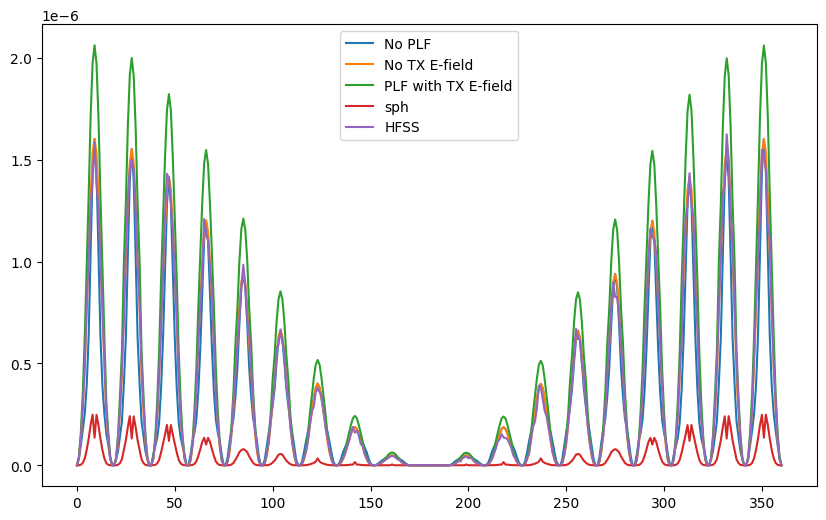

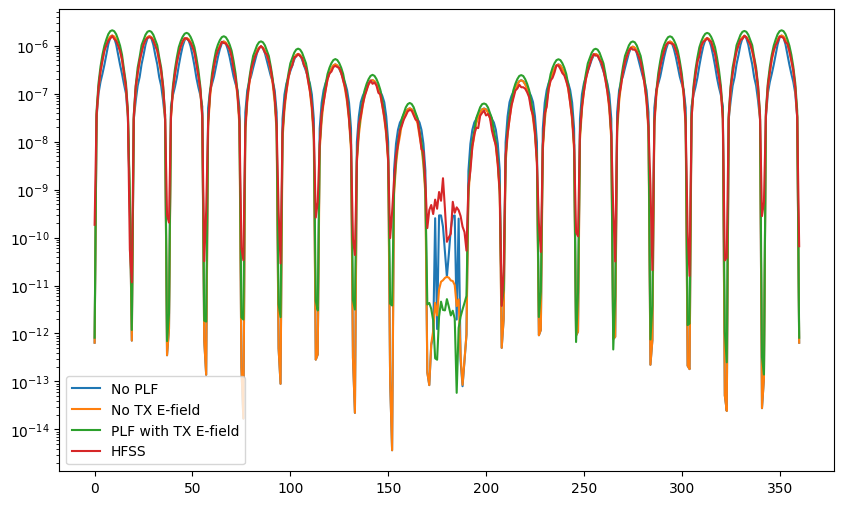

In [737]:
P_meas = 10**(s12_bowtie[:, 50]/10)
s11_b100 = 1-10**(s11_bowtie[:, 50]/10)
s11_t100 = 1-10**(s11_t[:, 50]/10)
plt.figure(figsize=(10, 6))
plt.plot(P_noE * s11_b100/10, label='No PLF')
plt.plot(P_E_notx * s11_b100/10, label='No TX E-field')
plt.plot(P_E_yestx * s11_b100/scale_factor[arc_pxs], label='PLF with TX E-field')
plt.plot(P_sph, label='sph')
plt.plot(P_meas, label='HFSS')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.semilogy(P_noE/10, label='No PLF')
plt.semilogy(P_E_notx/10, label='No TX E-field')
plt.semilogy(P_E_yestx, label='PLF with TX E-field')
plt.semilogy(P_meas, label='HFSS')
plt.legend()
plt.show()

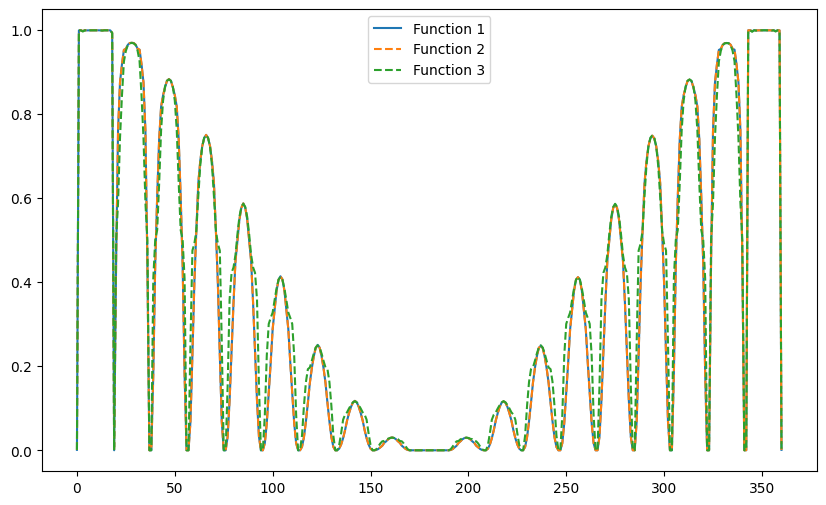

In [681]:
plt.figure(figsize=(10, 6))
plt.plot(plf_yestx, label='Function 1')
plt.plot(plf_notx,'--', label='Function 2')
# plt.plot(plf_diag)
plt.plot(plf_noE, '--', label='Function 3')
# plt.plot(P_E_yestx, label='PLF with TX E-field')
# plt.plot(P_meas, label='HFSS')
plt.legend()
plt.show()

In [682]:
def rms_err(pred, hfss):
    top = jnp.sum(jnp.abs(pred - hfss)**2)
    bottom = jnp.sum(jnp.abs(hfss)**2)
    return jnp.sqrt(top/bottom)

rms_err(P_noE * s11_b100/10, P_meas), rms_err(P_E_notx * s11_b100/10, P_meas), rms_err(P_E_yestx, P_meas)

(Array(0.23030193, dtype=float64),
 Array(0.05741251, dtype=float64),
 Array(0.33184617, dtype=float64))

In [738]:

# @jax.jit
# def simulate_powers_vmap_phase_sph(rx, tx, az, el, E1, E2,                   # kept for parity
#                                delta_rx=0.0,
#                                pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
#                                K=1.0, C0=0.0, noise=None):
#     # defaults from rx
#     # if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
#     # if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi
#     if pwr_beam_th is None:  pwr_beam_th  = bowtie_theta_beam_100
#     if pwr_beam_phi is None: pwr_beam_phi = bowtie_phi_beam_100

#     # geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

#     # TX field in RX-local frame
#     Es = jax.vmap(tx.E_rotated)(Rs) ### original
#     # TX field in RX-local frame (current)
#     # Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3)
    
#     # --- NEW: enforce E ⟂ r_hat (transverse field) ---
#     r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### just added
#     Er = jnp.einsum('ij,ij->i', Es, r_hat)     ###
#     Es = Es - Er[:, None] * r_hat             ###

#     # local spherical basis and projections
#     th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
#     phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
#     # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
#     # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
#     Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
#     Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

#     # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
#     # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
#     # ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
#     ex = jnp.array([1, 0, 0]) / jnp.linalg.norm(jnp.array([1, 0, 0]))
#     alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
#     beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

#     # gather component gains (LINEAR units; if dBi, convert upstream)
#     pxs  = pxs.astype(jnp.int32)
#     Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
#     Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

#     # coherent single-port combination
#     a = jnp.sqrt(Gth)  * alpha
#     b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
#     V = a * Eth + b * Ephi

#     # auto-correlation (zero lag) power
#     P = (V.conj() * V).real * K_E**2 * free_space

#     if noise != None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=(P.shape))*noise
#     # return P, pxs
#     return P#, pxs, Eth, Ephi, alpha, beta


@jax.jit
def simulate_powers_vmap_phase_sph(
    rx, tx, az, el, E1, E2,
    delta_rx=0.0,
    pwr_beam_th=None, pwr_beam_phi=None,
    K=1.0, C0=0.0, noise=None
):
    if pwr_beam_th is None:
        pwr_beam_th = bowtie_theta_beam_100
    if pwr_beam_phi is None:
        pwr_beam_phi = bowtie_phi_beam_100

    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local Cartesian frame
    Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3), complex

    # Radial unit vector
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype)

    # Enforce transverse field
    Er = jnp.einsum('ij,ij->i', Es, r_hat)
    Es_t = Es - Er[:, None] * r_hat

    # Spherical tangent basis
    th_hat  = rx.th_hat(ths, phis).astype(Es.dtype)
    phi_hat = rx.phi_hat(ths, phis).astype(Es.dtype)

    pxs = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

    ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype)

    # Build effective receive polarization vector directly in Cartesian coordinates
    u_rx = (
        jnp.sqrt(Gth)[:, None]  * jnp.einsum('j,ij->i', ex, th_hat)[:, None] * th_hat
        + jnp.sqrt(Gphi)[:, None] * jnp.einsum('j,ij->i', ex, phi_hat)[:, None] * jnp.exp(1j * delta_rx) * phi_hat
    )

    # One scalar port voltage
    V = jnp.einsum('ij,ij->i', Es_t, u_rx)

    P = (V.conj() * V).real * K_E**2 * free_space

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, P.shape) * noise

    return P

In [739]:
tx = TransmitterAntenna(E1=1.0, E2=0.0, heading_top=coord, alpha=0) # 100MHz?
P_sph = simulate_powers_vmap_phase_sph(tx=tx, rx=rx, 
                                                        az=az_inds, el=el_inds, 
                                                        E1=0, E2=0, delta_rx=delta_rx)

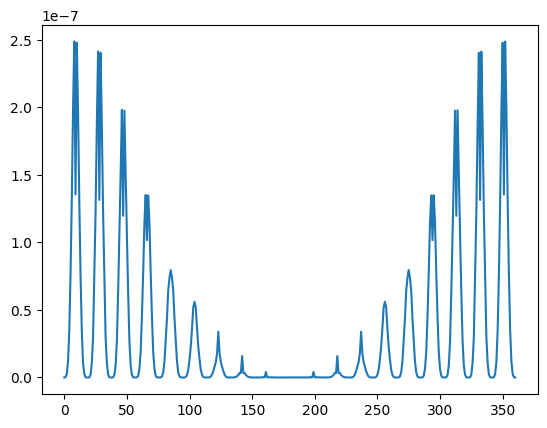

In [740]:
plt.figure()
plt.plot(P_sph)
plt.show()